# 📊 01 — Eksplorasi Data

Notebook ini digunakan untuk:
1. Memuat dan memeriksa dataset mentah
2. Memahami distribusi fitur antar kelas aktivitas
3. Mendeteksi outlier dan nilai yang tidak wajar
4. Visualisasi scatter plot dan distribusi untuk membantu tuning threshold

**Jalankan `data_collection.py` terlebih dahulu** untuk menghasilkan `dataset/dataset.csv`.

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from config import DATASET_PATH, CLASSES, FEATURES, TARGET
from utils  import load_and_clean_dataset, class_distribution, get_logger

logger = get_logger('notebook_01')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 5)
print('Library siap.')

Library siap.


## 1. Muat Dataset

In [2]:
df = load_and_clean_dataset(DATASET_PATH)
print(f'Shape dataset: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
df.head(10)

Shape dataset: (179, 6)
Kolom: ['accel_stddev', 'gyro_stddev', 'activity', 'bpm', 'user', 'received_at']


,accel_stddev,gyro_stddev,activity,bpm,user,received_at
0,0.006552,0.0291,DUDUK,0,User_001,2026-04-06T16:25:57.165405
1,0.005946,0.0236,DUDUK,0,User_001,2026-04-06T16:25:59.114239
2,0.005978,0.0152,DUDUK,0,User_001,2026-04-06T16:26:01.161113
3,0.005402,0.0189,DUDUK,0,User_001,2026-04-06T16:26:03.208918
4,0.005159,0.0193,DUDUK,0,User_001,2026-04-06T16:26:05.116394
5,0.009098,0.0201,DUDUK,0,User_001,2026-04-06T16:26:07.202745
6,0.008110,0.0242,DUDUK,0,User_001,2026-04-06T16:26:09.150671
7,0.010737,15.8778,DUDUK,37,User_001,2026-04-06T16:26:11.195937
8,0.009077,6.3718,DUDUK,55,User_001,2026-04-06T16:26:13.333015
9,0.007379,1.7248,DUDUK,70,User_001,2026-04-06T16:26:15.192891


In [3]:
print('\n=== INFO DATASET ===')
df.info()

print('\n=== STATISTIK DESKRIPTIF ===')
df[FEATURES].describe().round(5)


=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   accel_stddev  179 non-null    float64
 1   gyro_stddev   179 non-null    float64
 2   activity      179 non-null    str    
 3   bpm           179 non-null    int64  
 4   user          179 non-null    str    
 5   received_at   179 non-null    str    
dtypes: float64(2), int64(1), str(3)
memory usage: 8.5 KB

=== STATISTIK DESKRIPTIF ===


,accel_stddev,gyro_stddev
count,179.00000,179.00000
mean,0.07764,20.74920
std,0.06664,16.06511
min,0.00374,0.01520
25%,0.00888,1.11135
50%,0.07263,24.99430
75%,0.13454,33.04205
max,0.25302,58.73380


## 2. Distribusi Kelas

=== DISTRIBUSI KELAS ===
          count    pct
activity              
DUDUK        60  33.52
BERJALAN     60  33.52
BERLARI      59  32.96


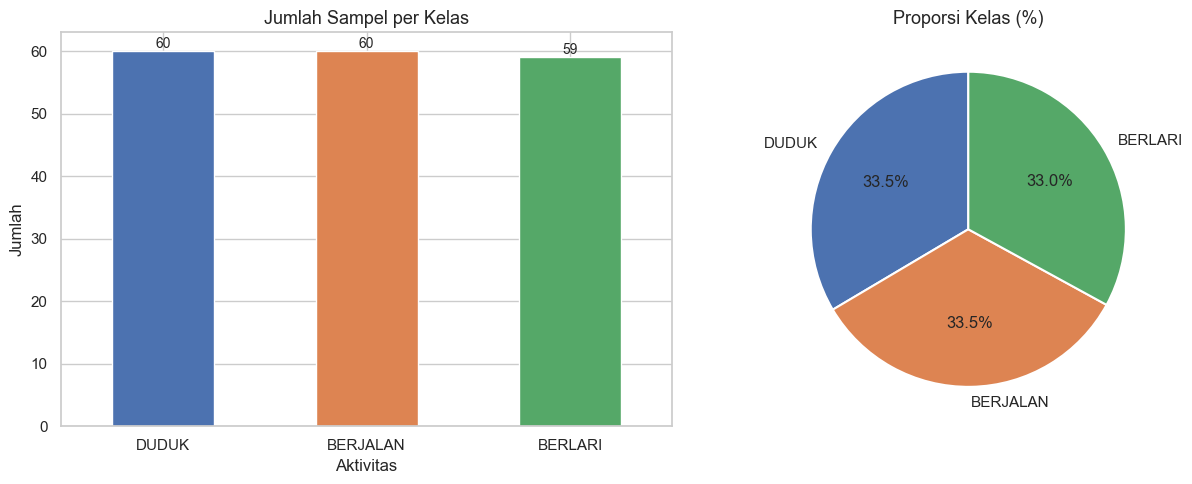

✅  Dataset cukup seimbang.


In [4]:
dist = class_distribution(df)
print('=== DISTRIBUSI KELAS ===')
print(dist.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart jumlah
colors = ['#4C72B0', '#DD8452', '#55A868']
dist['count'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Jumlah Sampel per Kelas', fontsize=13)
axes[0].set_xlabel('Aktivitas')
axes[0].set_ylabel('Jumlah')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart persen
axes[1].pie(dist['count'], labels=dist.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Proporsi Kelas (%)', fontsize=13)

plt.tight_layout()
plt.savefig('../data/processed/distribusi_kelas.png', dpi=150)
plt.show()

# Peringatan imbalance
min_pct = dist['pct'].min()
if min_pct < 20:
    print(f'⚠️  Dataset tidak seimbang! Kelas terkecil hanya {min_pct:.1f}%.')
    print('   Pertimbangkan mengumpulkan lebih banyak data untuk kelas tersebut.')
else:
    print('✅  Dataset cukup seimbang.')

## 3. Distribusi Fitur per Kelas

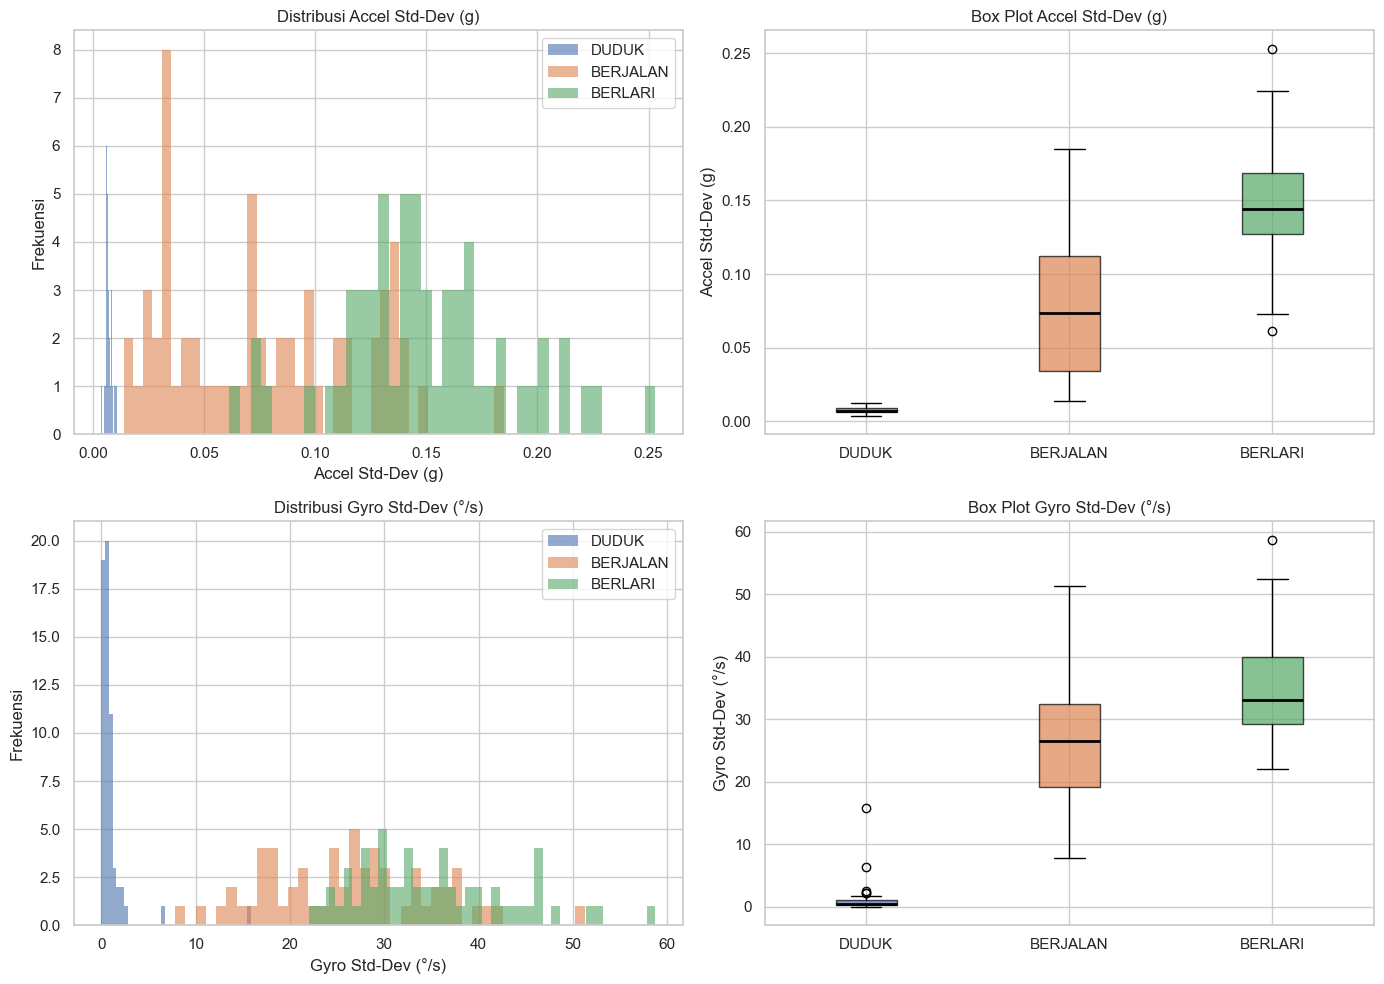

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
color_map = dict(zip(CLASSES, colors))

for row_idx, feat in enumerate(FEATURES):
    feat_label = 'Accel Std-Dev (g)' if 'accel' in feat else 'Gyro Std-Dev (°/s)'

    # Histogram overlay
    ax = axes[row_idx][0]
    for cls in CLASSES:
        subset = df[df[TARGET] == cls][feat]
        ax.hist(subset, bins=40, alpha=0.6, color=color_map[cls], label=cls, edgecolor='none')
    ax.set_title(f'Distribusi {feat_label}', fontsize=12)
    ax.set_xlabel(feat_label)
    ax.set_ylabel('Frekuensi')
    ax.legend()

    # Box plot
    ax2 = axes[row_idx][1]
    data_per_class = [df[df[TARGET] == cls][feat].values for cls in CLASSES]
    bp = ax2.boxplot(data_per_class, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xticks(range(1, len(CLASSES)+1))
    ax2.set_xticklabels(CLASSES)
    ax2.set_title(f'Box Plot {feat_label}', fontsize=12)
    ax2.set_ylabel(feat_label)

plt.tight_layout()
plt.savefig('../data/processed/distribusi_fitur.png', dpi=150)
plt.show()

## 4. Scatter Plot 2D — Separabilitas Kelas

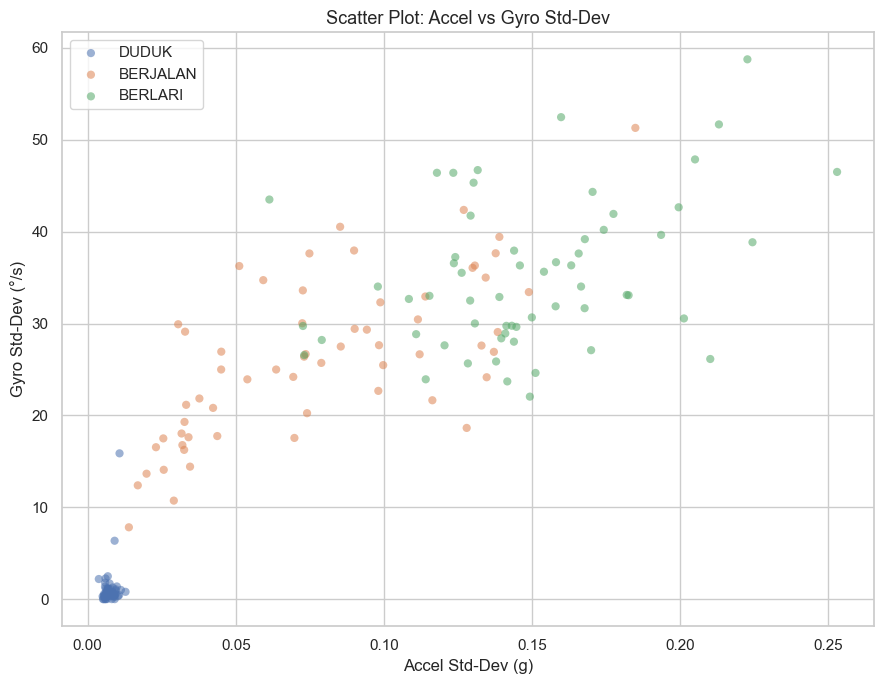

Jika ketiga kelas terlihat terpisah → fitur sudah baik untuk KNN.
Jika tumpang tindih banyak → pertimbangkan tambah fitur atau tuning threshold ESP32.


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))

for cls, color in zip(CLASSES, colors):
    subset = df[df[TARGET] == cls]
    ax.scatter(
        subset['accel_stddev'], subset['gyro_stddev'],
        c=color, label=cls, alpha=0.55, edgecolors='none', s=35
    )

ax.set_xlabel('Accel Std-Dev (g)', fontsize=12)
ax.set_ylabel('Gyro Std-Dev (°/s)', fontsize=12)
ax.set_title('Scatter Plot: Accel vs Gyro Std-Dev', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../data/processed/scatter_2d.png', dpi=150)
plt.show()

print('Jika ketiga kelas terlihat terpisah → fitur sudah baik untuk KNN.')
print('Jika tumpang tindih banyak → pertimbangkan tambah fitur atau tuning threshold ESP32.')

## 5. Statistik Per Kelas (Panduan Tuning Threshold)

In [7]:
print('=== STATISTIK PER KELAS (gunakan untuk tuning threshold ESP32) ===')
for feat in FEATURES:
    unit = 'g' if 'accel' in feat else '°/s'
    print(f'\n  {feat} ({unit}):')
    for cls in CLASSES:
        subset = df[df[TARGET] == cls][feat]
        print(f'    {cls:<10s}: mean={subset.mean():.4f}  std={subset.std():.4f}  '
              f'min={subset.min():.4f}  max={subset.max():.4f}  '
              f'p5={subset.quantile(0.05):.4f}  p95={subset.quantile(0.95):.4f}')

=== STATISTIK PER KELAS (gunakan untuk tuning threshold ESP32) ===

  accel_stddev (g):
    DUDUK     : mean=0.0075  std=0.0018  min=0.0037  max=0.0128  p5=0.0054  p95=0.0106
    BERJALAN  : mean=0.0774  std=0.0426  min=0.0139  max=0.1849  p5=0.0229  p95=0.1385
    BERLARI   : mean=0.1492  std=0.0385  min=0.0613  max=0.2530  p5=0.0784  p95=0.2141

  gyro_stddev (°/s):
    DUDUK     : mean=1.0662  std=2.1517  min=0.0152  max=15.8778  p5=0.0201  p95=2.2816
    BERJALAN  : mean=26.1993  std=8.7477  min=7.8342  max=51.2773  p5=13.5999  p95=39.4748
    BERLARI   : mean=35.2232  std=8.0558  min=22.0459  max=58.7338  p5=24.5558  p95=48.2266


## 6. Deteksi Outlier (Z-Score)

In [8]:
from scipy.stats import zscore

z_scores = df[FEATURES].apply(zscore)
outliers = (z_scores.abs() > 3).any(axis=1)

print(f'Total outlier (|z| > 3): {outliers.sum()} dari {len(df)} baris ({outliers.mean()*100:.1f}%)')
if outliers.sum() > 0:
    print('\nContoh outlier:')
    display(df[outliers].head(10))
else:
    print('✅  Tidak ada outlier signifikan.')

Total outlier (|z| > 3): 0 dari 179 baris (0.0%)
✅  Tidak ada outlier signifikan.


## 7. Korelasi Fitur

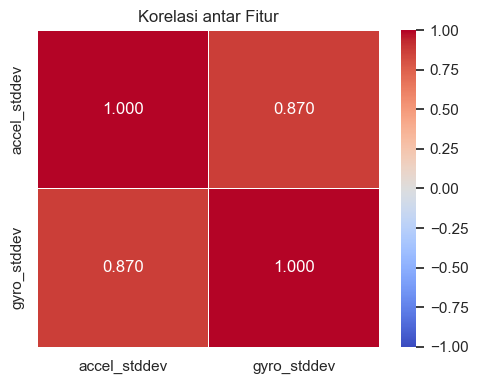

Catatan: Korelasi tinggi antar fitur bukan masalah besar untuk KNN,
tapi bisa dipertimbangkan untuk PCA jika fitur ditambah.


In [9]:
corr = df[FEATURES].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5)
plt.title('Korelasi antar Fitur')
plt.tight_layout()
plt.savefig('../data/processed/korelasi_fitur.png', dpi=150)
plt.show()

print('Catatan: Korelasi tinggi antar fitur bukan masalah besar untuk KNN,')
print('tapi bisa dipertimbangkan untuk PCA jika fitur ditambah.')

In [10]:
# Simpan dataset bersih
clean_path = '../data/processed/dataset_clean.csv'
df.to_csv(clean_path, index=False)
print(f'✅  Dataset bersih disimpan → {clean_path}')
print(f'   Shape: {df.shape}')

✅  Dataset bersih disimpan → ../data/processed/dataset_clean.csv
   Shape: (179, 6)
